# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Edición 2025**

---
## Gráfico del problema 3 del entregable Parte 2

In [17]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn

seaborn.set_context('talk')

In [18]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)

In [19]:
df[:10]

,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,salir_o_seguir_contestando_sobre_las_guardias,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.00,5800000.00,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.00
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.00,10200000.00,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.00
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.00,3137662.00,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.00
3,3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.00,1360000.00,Cobro parte del salario en dólares,1004,No,No recibo bono,...,NaN,NaN,NaN,NaN,25,Hombre Cis,Sí,True,Semi-Senior,1606000.00
4,4,Córdoba,Full-Time,Tercerizado (trabajo a través de consultora o ...,1325301.00,NaN,Cobro parte del salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,22,Hombre Cis,Sí,True,Senior,1325301.00
5,5,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),2670205.00,2167989.00,Cobro parte del salario en dólares,986,No,No recibo bono,...,Terminar encuesta,No,0.0,Porcentaje de mi sueldo bruto,48,Hombre Cis,Sí,True,Senior,2670205.00
6,6,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),4000000.00,4000000.00,Cobro todo el salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,No,0.0,Bruto,50,Hombre Cis,Sí,True,Senior,4000000.00
7,7,Córdoba,Full-Time,Staff (planta permanente),4200000.00,3600000.00,Cobro parte del salario en dólares,1070,No,No recibo bono,...,Responder sobre guardias,"Sí, pasiva",0.0,Porcentaje de mi sueldo bruto,43,Hombre Cis,Sí,True,Senior,4200000.00
8,8,Buenos Aires,Full-Time,Freelance,3000000.00,2000000.00,Mi sueldo está dolarizado (pero cobro en moned...,1150,No,No recibo bono,...,NaN,NaN,NaN,NaN,41,Hombre Cis,No,True,Senior,3000000.00
9,9,Buenos Aires,Full-Time,Staff (planta permanente),3953142.06,3258576.49,Mi sueldo está dolarizado (pero cobro en moned...,NaN,Un sueldo,Performance de la compañía,...,NaN,NaN,NaN,NaN,47,Hombre Cis,Sí,True,Senior,3953142.06


In [20]:
# Las columnas relevantes son las siguientes:
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO']

In [21]:
# Para ver qué filas son relevantes, hagamos un análisis sobre las columnas numéricas relevantes
relevant_numeric_columns = ['salary_monthly_NETO']
df[relevant_numeric_columns].describe().map(lambda x: round(x, 2))

,salary_monthly_NETO
count,4.951000e+03
mean,1.072550e+10
std,7.545122e+11
min,4.000000e+00
25%,1.288264e+06
50%,1.916958e+06
75%,2.893500e+06
max,5.309001e+13


In [22]:
# Armamos un nuevo DataFrame que filtra los datos, recortando las filas que se encuentran por encima
# del percentil 99 y por debajo del percentil 1 para todas las columnas numéricas relevantes
df_filtered = df.copy()  # trabajamos sobre una copia

for col in relevant_numeric_columns:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]

In [23]:
# Veamos ahora el resumen estadístico del nuevo dataframe
df_filtered[relevant_numeric_columns].describe().map(lambda x: round(x, 2))

,salary_monthly_NETO
count,4852.00
mean,2248259.43
std,1355399.87
min,250000.00
25%,1300000.00
50%,1914251.50
75%,2808051.46
max,8500000.00


In [24]:
# Hay más Full-Time, usemos estos
df_filtered = df_filtered[df_filtered['work_dedication'] == 'Full-Time']

In [25]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df_filtered.loc[:, 'cured_programming_languages'] = df_filtered.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df_filtered.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df_filtered[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,cured_programming_languages
2,sql,SQL,3137662.0,[sql]
6,.net,".NET, Python, SQL",4000000.0,"[.net, python, sql]"
6,python,".NET, Python, SQL",4000000.0,"[.net, python, sql]"
6,sql,".NET, Python, SQL",4000000.0,"[.net, python, sql]"
7,c++,"C++, Python",3600000.0,"[c++, python]"


In [26]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'programming_language': 'language', 'count': 'frequency'})
    #.rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:10]

,language,frequency
0,sql,2089
1,javascript,1709
2,python,1508
3,html,1232
4,typescript,949
5,css,861
6,bash/shell,802
7,java,774
8,php,570
9,.net,545


In [27]:
interesting_languages = ["python","javascript", "typescript", "java", "php", ".net", "c#", "go", "kotlin", "ruby"]
interesting_languages = ["javascript", "go", "kotlin", "ruby"]

In [28]:
filtered_df_lang = df_lang[df_lang.programming_language.isin(interesting_languages)]
filtered_df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,cured_programming_languages
12,javascript,"Javascript, TypeScript",4780000.0,"[javascript, typescript]"
19,javascript,"HTML, Javascript, Python, TypeScript",1564000.0,"[html, javascript, python, typescript]"
21,javascript,".NET, C#, HTML, Javascript, SQL",2500000.0,"[.net, c#, html, javascript, sql]"
24,javascript,"Javascript, PHP, Python, SQL, TypeScript",3000000.0,"[javascript, php, python, sql, typescript]"
25,javascript,"CSS, HTML, Javascript, TypeScript",540000.0,"[css, html, javascript, typescript]"


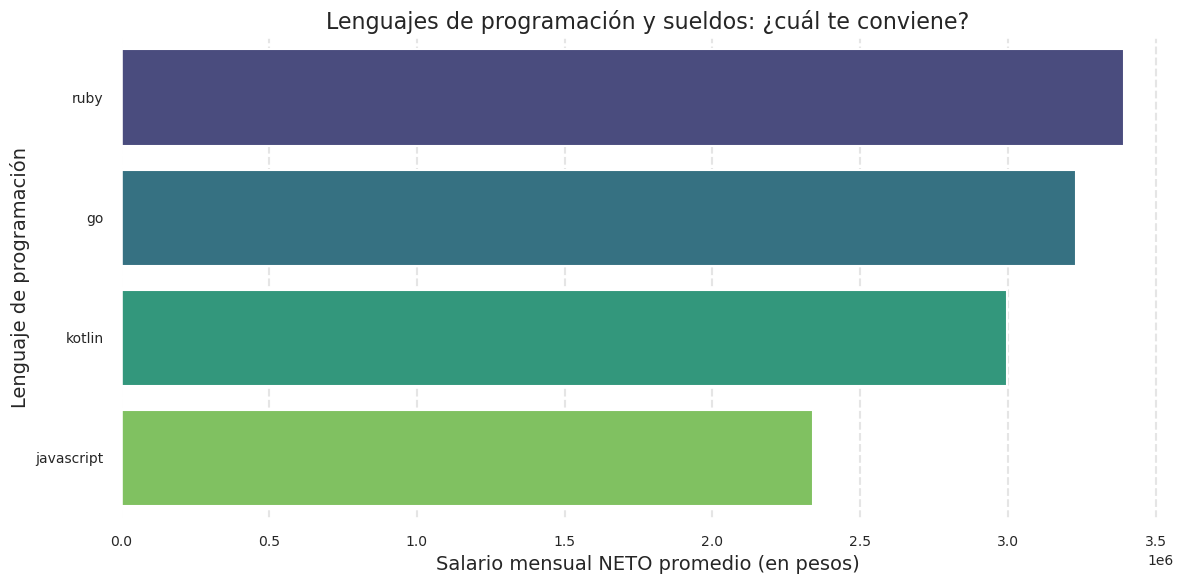

In [29]:
# Agrupamos por lenguaje y calculamos la media de salario
mean_salary_by_lang = (
    filtered_df_lang
    .groupby('programming_language')['salary_monthly_NETO']
    .mean()
    .sort_values(ascending=False)
)

# Estilo limpio
seaborn.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.edgecolor': 'white'
})

# Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
seaborn.barplot(
    x=mean_salary_by_lang.values,
    y=mean_salary_by_lang.index,
    hue=mean_salary_by_lang.index,
    palette='viridis',
)

# Etiquetas
plt.xlabel('Salario mensual NETO promedio (en pesos)')
plt.ylabel('Lenguaje de programación')
plt.title('Lenguajes de programación y sueldos: ¿cuál te conviene?')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('graph_p3_entregable2', dpi=300)
plt.show()